Project Week 2: Spam Detector

Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay


Step 2: Load Dataset

In [2]:
data = pd.read_csv('spam_ham_dataset.csv')
data

,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0
...,...,...,...,...
5166,1518,ham,Subject: put the 10 on the ft\r\nthe transport...,0
5167,404,ham,Subject: 3 / 4 / 2000 and following noms\r\nhp...,0
5168,2933,ham,Subject: calpine daily gas nomination\r\n>\r\n...,0
5169,1409,ham,Subject: industrial worksheets for august 2000...,0


Step 3: Drop unnamed column

In [3]:
data = data.drop('Unnamed: 0', axis=1)
data

,label,text,label_num
0,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,spam,"Subject: photoshop , windows , office . cheap ...",1
4,ham,Subject: re : indian springs\r\nthis deal is t...,0
...,...,...,...
5166,ham,Subject: put the 10 on the ft\r\nthe transport...,0
5167,ham,Subject: 3 / 4 / 2000 and following noms\r\nhp...,0
5168,ham,Subject: calpine daily gas nomination\r\n>\r\n...,0
5169,ham,Subject: industrial worksheets for august 2000...,0


Step 4: Explore Dataset

In [4]:
data['label'].value_counts()

label
ham     3672
spam    1499
Name: count, dtype: int64

Step 5: Spam vs Ham Distribution

Text(0.5, 1.0, 'Spam vs Ham Distribution')

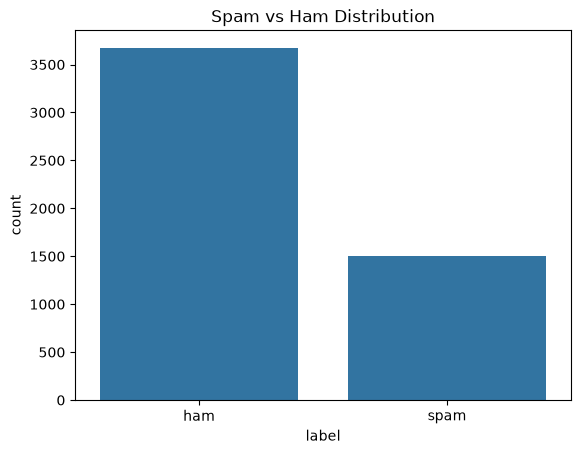

In [5]:
sns.countplot(x='label', data=data)
plt.title('Spam vs Ham Distribution')

Step 6: Clean Dataset

In [6]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\bsubject\b', '', text) # remove the repeated "Subject:" prefix
    text = re.sub(r'[\r\n]+', ' ', text) # remove line breaks
    text = re.sub(r'[^a-z\s]', '', text) # remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip() # collapse any extra whitespace
    return text

data['clean_text'] = data['text'].apply(clean_text)
data[['text', 'clean_text']].head()
data

,label,text,label_num,clean_text
0,ham,Subject: enron methanol ; meter # : 988291\r\n...,0,enron methanol meter this is a follow up to th...
1,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0,hpl nom for january see attached file hplnol x...
2,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0,neon retreat ho ho ho we re around to that mos...
3,spam,"Subject: photoshop , windows , office . cheap ...",1,photoshop windows office cheap main trending a...
4,ham,Subject: re : indian springs\r\nthis deal is t...,0,re indian springs this deal is to book the tec...
...,...,...,...,...
5166,ham,Subject: put the 10 on the ft\r\nthe transport...,0,put the on the ft the transport volumes decrea...
5167,ham,Subject: 3 / 4 / 2000 and following noms\r\nhp...,0,and following noms hpl can t take the extra mm...
5168,ham,Subject: calpine daily gas nomination\r\n>\r\n...,0,calpine daily gas nomination julie as i mentio...
5169,ham,Subject: industrial worksheets for august 2000...,0,industrial worksheets for august activity atta...


Step 7: Train and Split Dataset

In [7]:
x = data['clean_text']
y = data['label_num']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y) # stratify will help keep the spam/ham ratio equal as there is an unequal number of spams and hams

Step 8: Convert text to vectors using vectorizer

In [8]:
vector = TfidfVectorizer(stop_words='english', max_features=5000) # this should remove irrelevant words not used for spam and ham

x_train_vec = vector.fit_transform(x_train)
x_test_vec = vector.transform(x_test)

Step 9: Train the model

In [9]:
model = MultinomialNB()
model.fit(x_train_vec, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](2,)","[2937.,1199.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](2,)","[-0.34,-1.24]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](2, 5000)","[[0.53,2.21,0.39,...,0. ,0.42,0. ], [1.94,0. ,0.41,...,1.6 ,0.46,2.1 ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](2, 5000)","[[-9.41,-8.67,-9.51,...,-9.84,-9.49,-9.84], [-8.23,-9.31,-8.97,...,-8.35,-8.93,-8.18]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5000


Step 10: Predict and evaluate the model

              precision    recall  f1-score   support

         ham       0.97      0.96      0.96       735
        spam       0.90      0.93      0.91       300

    accuracy                           0.95      1035
   macro avg       0.93      0.94      0.94      1035
weighted avg       0.95      0.95      0.95      1035



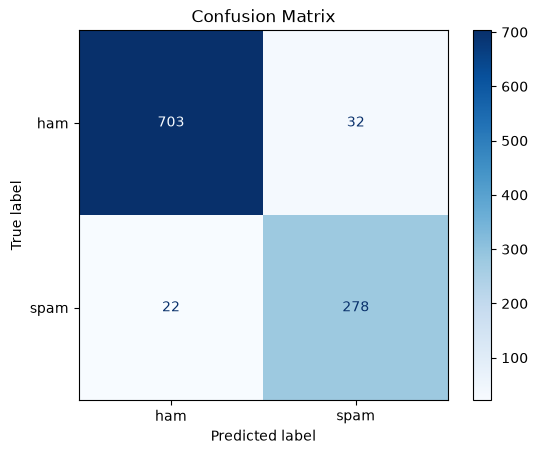

In [10]:
y_pred = model.predict(x_test_vec)

print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ham', 'spam'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

Evaluation Result: The model achieved 95%  accuracy, it correctly classifies 981 out of 1,035 emails. It performs slightly better on ham with an F1 score of 0.96 than spam that has an F1 score 0.91, which reflects the class imbalance in the training data which has approximately 71% ham vs 29% spam. Of the 54 misclassifications, 32 were legitimate emails incorrectly flagged as spam (false positives), while 22 were spam emails that slipped through undetected (false negatives). In a real-world spam filter, false positives are generally the more costly error, since important emails could be missed if routed to spam. Overall, this represents strong baseline performance from a Naive Bayes classifier.

Step 11: Save the model

In [11]:
from sklearn.pipeline import Pipeline
import joblib

# Build a pipeline combining the vector + model
pipeline = Pipeline([
    ('tfidf', vector),
    ('classifier', model)
])

# Re-fit the pipeline on raw training text (not the pre-vectorized version)
pipeline.fit(x_train, y_train)

# Save the pipeline as a file
joblib.dump(pipeline, 'spam_detector_pipeline_naivebayers.pkl')

['spam_detector_pipeline_naivebayers.pkl']

Step 12: Reuse model with example emails

In [12]:
# Load the pipeline
loaded_pipeline = joblib.load('spam_detector_pipeline_naivebayers.pkl')

# Example emails
new_emails = [
    "Hey love, I wanted to text you",
    "Hi Bongani, please find attached the report for review and make adjustments for the meeting tomorrow.",
    "Hello handsome stranger, how are you tonight?",
    "Welcome! Claim HK$350 in vouchers + G-coins + referral rewards.",
    "I'm your dirty. bhekifuzwayo.",
    "Make tonight feel different.A private space for bold moods, unforgettable chemistry, and moments made just for you.",
    "Dear Valued Merchant, Greetings from Fiuu! We would like to remind you on the request additional documentation or information regarding your business in order to process your application ( Application ID: 124511 ). Please submit the requested document by clicking the button below before 28 August 2026 to avoid your account being set to inactive. You may not be able to proceed with transactions under an inactive account status.",
    "Here is my main e-mail! Bonganibhekisipho hiya!",
    "Dear bassists, Released in 1965, Day Tripper is driven by one of The Beatles' most distinctive riffs, with a bass part that reinforces the track's blues-rock character and energetic rhythm. Stay tightly connected to the main riff and keep each note clean and precise, paying particular attention to the rhythmic accents throughout the song. This arrangement is available with a high-quality backing track, and the Original Version is also available in our catalogue. You can also explore our collection of the best of The Beatles.",
    "Hello Bongani‌, There’s still time to save up to 20%* on flights to your next unforgettable adventure. Don't miss out! Book on qatarairways.com or our mobile app by 11 September 2026 for travel until 28 February 2027."

]

print("Number of emails:", len(new_emails))  # check if all emails in the new_emails are read immediately after creation

# Clean the new emails in the same way training data was cleaned
new_emails_clean = [clean_text(email) for email in new_emails]
predictions = loaded_pipeline.predict(new_emails_clean)

for email, pred in zip(new_emails, predictions):
    label = 'spam' if pred == 1 else 'ham'
    result = f"'{email[:50]}...' -> {label}"
    print(result)

Number of emails: 10
'Hey love, I wanted to text you...' -> ham
'Hi Bongani, please find attached the report for re...' -> ham
'Hello handsome stranger, how are you tonight?...' -> spam
'Welcome! Claim HK$350 in vouchers + G-coins + refe...' -> spam
'I'm your dirty. bhekifuzwayo....' -> ham
'Make tonight feel different.A private space for bo...' -> spam
'Dear Valued Merchant, Greetings from Fiuu! We woul...' -> ham
'Here is my main e-mail! Bonganibhekisipho hiya!...' -> spam
'Dear bassists, Released in 1965, Day Tripper is dr...' -> spam
'Hello Bongani‌, There’s still time to save up to 2...' -> spam


Using model on new unseen emails: Testing the saved pipeline on new, unseen messages shows it correctly identifies clear promotional spam (e.g. "Claim HK$350 in vouchers...") and legitimate work correspondence as ham. However, it misclassifies some ambiguous personal messages, which is expected given the training data consists primarily of business and promotional emails rather than casual personal texts. This highlights that model performance depends heavily on how closely new input resembles the training distribution.

Step 13: Using logistic regression for comparison

In [13]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(x_train_vec, y_train)

lr_pred = lr_model.predict(x_test_vec)

print(classification_report(y_test, lr_pred, target_names=['ham', 'spam']))

              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       735
        spam       0.96      0.97      0.97       300

    accuracy                           0.98      1035
   macro avg       0.98      0.98      0.98      1035
weighted avg       0.98      0.98      0.98      1035



Step 14: Logistic regression confusion matrix

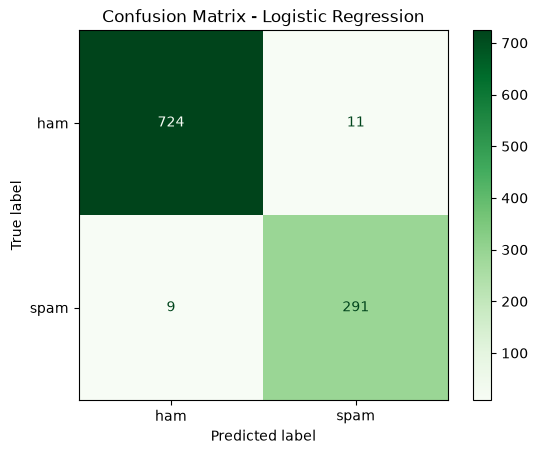

In [14]:
conmat_lr = confusion_matrix(y_test, lr_pred)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=conmat_lr, display_labels=['ham', 'spam'])
disp_lr.plot(cmap='Greens')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

Step 15: Model Comparison
Naive Bayes
Accuracy = 95%
Ham F1-score = 0.96
Spam F1-score = 0.91

Logistic Regression
Accuracy = 98%
Ham F1-score = 0.99
Spam F1-score = 0.97

Logistic Regression outperformed Naive Bayes across every metric, with a particularly notable improvement on spam detection as the F1-score shows 0.97 vs 0.91. This suggests Logistic Regression better captures the more nuanced word patterns that distinguish spam from ham in this dataset.

Step 16: Saving the model pipeline and using model with new unseen emails

In [16]:
lr_pipeline = Pipeline([
    ('tfidf', vector),
    ('classifier', lr_model)
])
lr_pipeline.fit(x_train, y_train)

joblib.dump(lr_pipeline, 'spam_detector_pipeline_logreg.pkl')
loaded_lr_pipeline = joblib.load('spam_detector_pipeline_logreg.pkl')

new_emails_clean = [clean_text(email) for email in new_emails]
lr_predictions = loaded_lr_pipeline.predict(new_emails_clean)

for email, pred in zip(new_emails, lr_predictions):
    label = 'spam' if pred == 1 else 'ham'
    print(f"'{email[:50]}...' -> {label}")

'Hey love, I wanted to text you...' -> spam
'Hi Bongani, please find attached the report for re...' -> ham
'Hello handsome stranger, how are you tonight?...' -> spam
'Welcome! Claim HK$350 in vouchers + G-coins + refe...' -> spam
'I'm your dirty. bhekifuzwayo....' -> spam
'Make tonight feel different.A private space for bo...' -> spam
'Dear Valued Merchant, Greetings from Fiuu! We woul...' -> ham
'Here is my main e-mail! Bonganibhekisipho hiya!...' -> spam
'Dear bassists, Released in 1965, Day Tripper is dr...' -> spam
'Hello Bongani‌, There’s still time to save up to 2...' -> spam


Step 17: Conclusion

This project built a spam email classifier using a labeled dataset of 5,171 emails. After cleaning the text and converting it into numeric features using TF-IDF vectorization, two classification models were trained and compared: Naive Bayes and Logistic Regression.

Model Comparison:

Logistic Regression outperformed Naive Bayes across every metric, with the largest improvement seen on spam detection specifically. Based on these results, Logistic Regression should be selected as the final model and its full pipeline was saved using joblib for reuse on new, unseen text.

Testing the saved pipeline on 10 new example messages showed it correctly flagged clear promotional and scam-style content (vouchers, urgent merchant notices with links, unsolicited offers) as spam, and correctly passed a genuine work email as ham. It also classified several casual or personal-style messages as spam  because of the informal, unstructured phrasing shares statistical similarities with spam text patterns in the training data, rather than because those messages contain traditional spam markers.

Limitations and future improvements
1. The training data skews toward business/promotional email content, so casual personal messages are underrepresented and harder for the model to classify accurately.
2. Class imbalance (71% ham vs 29% spam) may still influence certain predictions, despite stratified train/test splitting.
3. Future work could include testing additional models, tuning hyperparameters or expanding the training data with more diverse message styles to improve generalization on informal text.

I personally should note that for the example emails they came from both my inbox and spam folder so I would like to add that out of the 10 emails 2 came directly from my inbox with one labelled spam and the other labelled ham (Hello Bongani,... -> spam and Hi Bongani,.. -> ham). While the other 8 entries came from my spam folder with one labelled ham ( Dear Valued Merchant,... -> ham). With this context I can say that the Logistic Regression model did a better job in labelling spam than my own spam filters on my email further reinforcing the choice that this model should be used.